# Customer Annual Spending Prediction
**SI 422 Group Project (2025)** — Guide: Prof. Monika Bhattacharjee, IIT Bombay

This notebook walks through the full modelling pipeline interactively:

1. Load & clean data
2. EDA + Box-Cox transformation
3. One-hot encoding + standard scaling
4. Multicollinearity check (VIF)
5. Feature selection: AIC/BIC backward elimination, k-fold CV, Lasso
6. Final MLR model (R² / Adjusted R²)
7. Influential points: Cook's Distance, DFFITS
8. MLR assumption verification

For the production version of this pipeline (used to generate everything
in `results/`), see `src/analysis.py`. This notebook mirrors it step by
step with inline output so you can inspect each stage.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import boxcox

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LassoCV, LinearRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load & Clean Data

In [2]:
df = pd.read_csv("../data/customer_spending.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1200, 16)


,CustomerID,Age,Gender,Region,Annual_Income,Membership_Type,Membership_Years,Device_Preference,Avg_Session_Length_Min,App_Usage_Hours_Week,Website_Usage_Hours_Week,Num_Purchases_Last_Year,Customer_Satisfaction,Days_Since_Last_Purchase,Email_Engagement_Rate,Annual_Spending
0,1,31,Female,East,53218.35,Silver,6.98,Mobile App,32.22,1.09,1.40,14,9.37,16.8,0.249,5839.51
1,2,31,Male,East,53053.23,Gold,0.94,Mobile App,26.27,2.96,4.24,14,6.31,22.8,0.249,5717.21
2,3,31,Female,West,NaN,Gold,5.98,Website,42.09,3.23,0.86,18,10.00,22.9,0.542,7631.73
3,4,30,Female,East,93316.07,Platinum,0.15,Mobile App,24.24,4.77,1.22,10,9.05,26.3,0.356,7589.57
4,5,24,Male,North,61626.75,Gold,4.18,Both,29.61,1.22,4.23,10,7.14,5.1,0.227,6750.69


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Missing values before imputation:")
print(missing)

for col in missing.index:
    df[col] = df[col].fillna(df[col].median())

df = df.drop(columns=["CustomerID"])
print(f"\nMissing values after imputation: {df.isna().sum().sum()}")

Missing values before imputation:
Annual_Income            24
Customer_Satisfaction    17
Email_Engagement_Rate    11
dtype: int64

Missing values after imputation: 0


## 2. EDA — Distribution & Skewness

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skew_before = df[numeric_cols].skew().sort_values(ascending=False)
skew_before

Days_Since_Last_Purchase    2.116007
Membership_Years            1.870368
Website_Usage_Hours_Week    1.625282
App_Usage_Hours_Week        1.422240
Annual_Income               1.041331
Email_Engagement_Rate       0.524215
Annual_Spending             0.393958
Num_Purchases_Last_Year     0.333665
Age                         0.142827
Avg_Session_Length_Min      0.075081
Customer_Satisfaction      -0.131780
dtype: float64

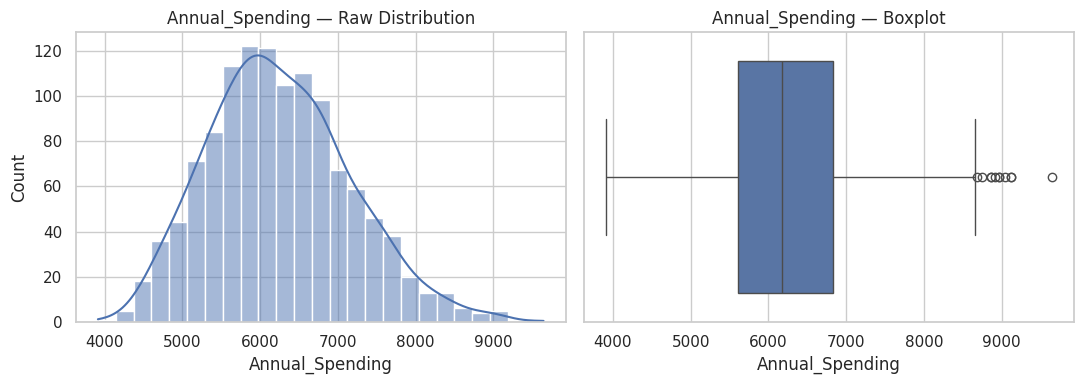

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Annual_Spending"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Annual_Spending — Raw Distribution")
sns.boxplot(x=df["Annual_Spending"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Annual_Spending — Boxplot")
plt.tight_layout()
plt.show()

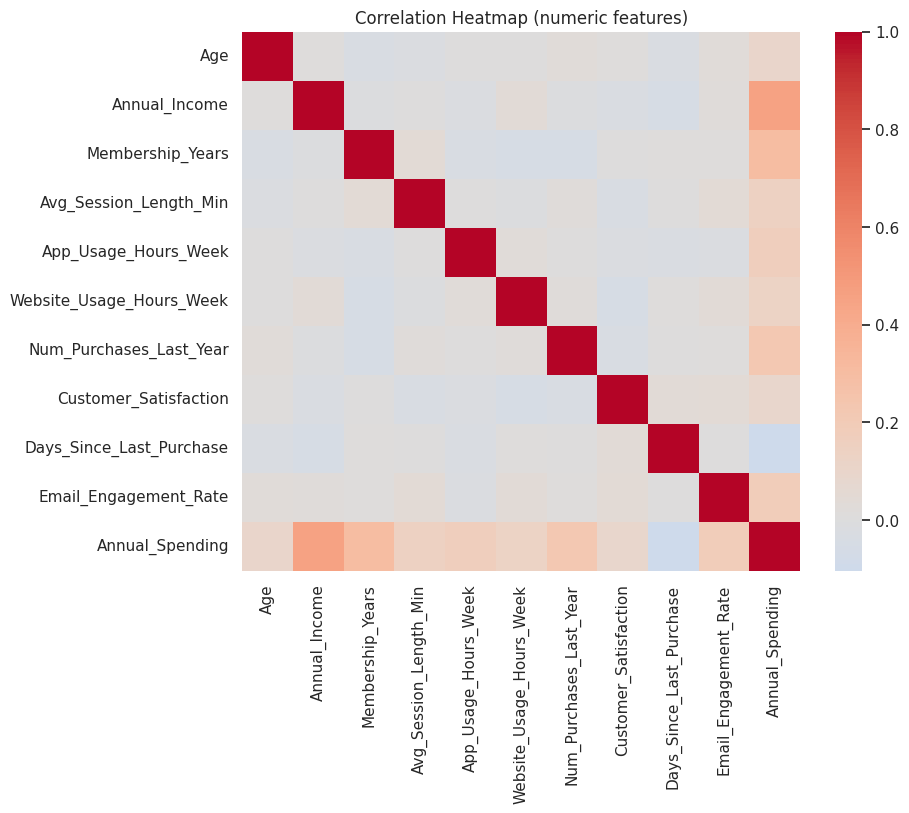

In [6]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

## 3. Box-Cox Transformation

Right-skewed numeric features (and the target) are Box-Cox transformed to stabilize variance and reduce skew.

In [7]:
boxcox_lambdas = {}
df_bc = df.copy()
candidates = [
    "Annual_Income", "Membership_Years", "Days_Since_Last_Purchase",
    "App_Usage_Hours_Week", "Website_Usage_Hours_Week",
    "Num_Purchases_Last_Year", "Annual_Spending",
]
for col in candidates:
    vals = df_bc[col].values
    shift = 0
    if (vals <= 0).any():
        shift = abs(vals.min()) + 1
    transformed, lam = boxcox(vals + shift)
    df_bc[col] = transformed
    boxcox_lambdas[col] = (round(lam, 4), shift)

pd.DataFrame(boxcox_lambdas, index=["lambda", "shift"]).T

,lambda,shift
Annual_Income,-0.0183,0.0
Membership_Years,0.2383,0.0
Days_Since_Last_Purchase,0.1652,1.0
App_Usage_Hours_Week,0.3396,0.0
Website_Usage_Hours_Week,0.2432,0.0
Num_Purchases_Last_Year,0.5802,0.0
Annual_Spending,-0.0282,0.0


Skewness after Box-Cox:
Annual_Spending             0.000354
Annual_Income               0.000168
Num_Purchases_Last_Year    -0.002979
Website_Usage_Hours_Week   -0.005744
App_Usage_Hours_Week       -0.012439
Days_Since_Last_Purchase   -0.038739
Membership_Years           -0.046409
dtype: float64


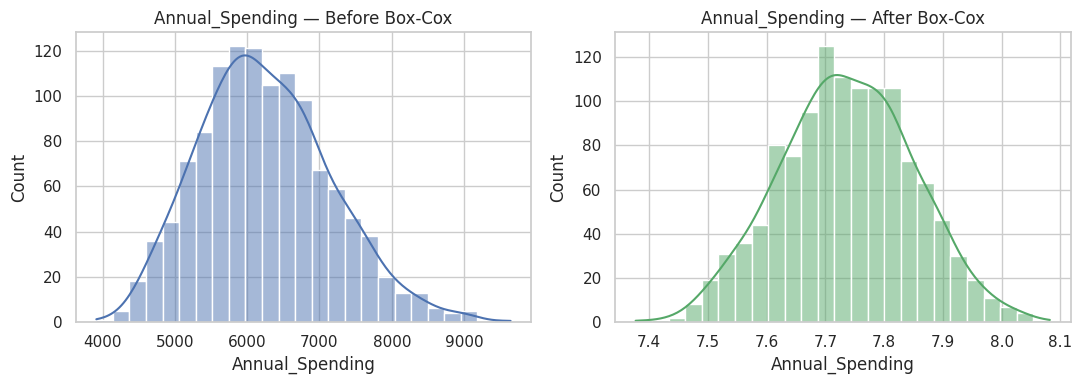

In [8]:
skew_after = df_bc[candidates].skew().sort_values(ascending=False)
print("Skewness after Box-Cox:")
print(skew_after)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Annual_Spending"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Annual_Spending — Before Box-Cox")
sns.histplot(df_bc["Annual_Spending"], kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Annual_Spending — After Box-Cox")
plt.tight_layout()
plt.show()

## 4. One-Hot Encoding + Standard Scaling

In [9]:
cat_cols = df_bc.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {cat_cols}")

df_enc = pd.get_dummies(df_bc, columns=cat_cols, drop_first=True)

target = "Annual_Spending"
feature_cols = [c for c in df_enc.columns if c != target]

scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df_enc[feature_cols]),
    columns=feature_cols,
    index=df_enc.index,
)
y = df_enc[target]

print(f"Feature matrix shape: {X.shape}")
X.head()

Categorical columns: ['Gender', 'Region', 'Membership_Type', 'Device_Preference']
Feature matrix shape: (1200, 19)


,Age,Annual_Income,Membership_Years,Avg_Session_Length_Min,App_Usage_Hours_Week,Website_Usage_Hours_Week,Num_Purchases_Last_Year,Customer_Satisfaction,Days_Since_Last_Purchase,Email_Engagement_Rate,Gender_Male,Region_North,Region_South,Region_West,Membership_Type_Gold,Membership_Type_Platinum,Membership_Type_Silver,Device_Preference_Mobile App,Device_Preference_Website
0,-0.679127,-0.074774,1.243553,0.484941,-1.148672,-0.370773,0.022876,1.434522,0.029777,-0.267975,-0.967204,-0.642983,-0.574784,-0.537528,-0.540103,-0.386556,1.533609,1.058367,-0.579916
1,-0.679127,-0.083503,-0.716710,-0.163044,-0.006646,1.142734,0.022876,-1.061529,0.315445,-0.267975,1.033908,-0.642983,-0.574784,-0.537528,1.851498,-0.386556,-0.652057,1.058367,-0.579916
2,-0.679127,-0.061983,1.056848,1.559834,0.112790,-0.917657,1.011341,1.948415,0.319669,1.561397,-0.967204,-0.642983,-0.574784,1.860367,1.851498,-0.386556,-0.652057,-0.944852,1.724387
3,-0.772940,1.494579,-1.850478,-0.384122,0.691637,-0.531845,-1.093830,1.173497,0.455210,0.400089,-0.967204,-0.642983,-0.574784,-0.537528,-0.540103,2.586949,-0.652057,1.058367,-0.579916
4,-1.335817,0.336718,0.649978,0.200698,-1.038391,1.139055,-1.093830,-0.384495,-0.912513,-0.405334,1.033908,1.555250,-0.574784,-0.537528,1.851498,-0.386556,-0.652057,-0.944852,-0.579916


## 5. Multicollinearity Check (VIF)

Iteratively drop the feature with the highest VIF until all remaining features are below the threshold (8.0).

In [10]:
def prune_by_vif(X, threshold=8.0):
    X_ = X.copy()
    dropped = []
    while True:
        X_const = sm.add_constant(X_)
        vifs = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns,
        ).drop("const")
        if vifs.max() > threshold:
            worst = vifs.idxmax()
            dropped.append((worst, round(vifs.max(), 2)))
            X_ = X_.drop(columns=[worst])
        else:
            return X_, vifs, dropped

X_vif, final_vifs, dropped_vif = prune_by_vif(X)
print(f"Dropped for high VIF: {dropped_vif if dropped_vif else 'None'}")
final_vifs.sort_values(ascending=False)

Dropped for high VIF: None


Region_North                    1.612679
Region_South                    1.565437
Region_West                     1.531967
Device_Preference_Website       1.462339
Device_Preference_Mobile App    1.445164
Membership_Type_Silver          1.329467
Membership_Type_Gold            1.292289
Membership_Type_Platinum        1.219854
Annual_Income                   1.017923
App_Usage_Hours_Week            1.016723
Membership_Years                1.016408
Age                             1.015665
Website_Usage_Hours_Week        1.015446
Num_Purchases_Last_Year         1.014383
Avg_Session_Length_Min          1.014050
Customer_Satisfaction           1.012112
Email_Engagement_Rate           1.011794
Days_Since_Last_Purchase        1.010843
Gender_Male                     1.009970
dtype: float64

## 6. Feature Selection

### 6a. AIC/BIC-Based Backward Elimination

In [11]:
def backward_elimination(X, y, criterion="bic"):
    features = list(X.columns)

    def fit_score(feats):
        X_const = sm.add_constant(X[feats])
        model = sm.OLS(y, X_const).fit()
        return (model.aic if criterion == "aic" else model.bic), model

    current_score, current_model = fit_score(features)
    improved = True
    while improved and len(features) > 1:
        improved = False
        best_score = current_score
        best_drop = None
        for f in features:
            trial = [x for x in features if x != f]
            score, _ = fit_score(trial)
            if score < best_score:
                best_score, best_drop = score, f
        if best_drop is not None:
            features.remove(best_drop)
            current_score, current_model = fit_score(features)
            improved = True
    return features, current_model

features_be, model_be = backward_elimination(X_vif, y, criterion="bic")
print(f"Selected {len(features_be)} features:")
print(features_be)

Selected 17 features:
['Age', 'Annual_Income', 'Membership_Years', 'Avg_Session_Length_Min', 'App_Usage_Hours_Week', 'Website_Usage_Hours_Week', 'Num_Purchases_Last_Year', 'Customer_Satisfaction', 'Days_Since_Last_Purchase', 'Email_Engagement_Rate', 'Region_North', 'Region_South', 'Membership_Type_Gold', 'Membership_Type_Platinum', 'Membership_Type_Silver', 'Device_Preference_Mobile App', 'Device_Preference_Website']


### 6b. K-Fold Cross Validation

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()
cv_scores = cross_val_score(lr, X_vif[features_be], y, cv=kf, scoring="r2")

print(f"R^2 per fold: {np.round(cv_scores, 4)}")
print(f"Mean CV R^2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

R^2 per fold: [0.8597 0.8347 0.8394 0.8868 0.8616]
Mean CV R^2: 0.8565 (+/- 0.0186)


### 6c. Lasso Regularization (independent cross-check)

In [13]:
lasso = LassoCV(cv=kf, random_state=42, max_iter=20000).fit(X_vif, y)
coefs = pd.Series(lasso.coef_, index=X_vif.columns)
kept = coefs[coefs.abs() > 1e-6].sort_values(key=abs, ascending=False)

print(f"Optimal alpha: {lasso.alpha_:.5f}")
print(f"Features shrunk to ~0 by Lasso: {coefs[coefs.abs() <= 1e-6].index.tolist()}")
print(f"\nOverlap with backward elimination: "
      f"{len(set(features_be) & set(kept.index))} / {len(features_be)} features")
kept

Optimal alpha: 0.00005
Features shrunk to ~0 by Lasso: []

Overlap with backward elimination: 17 / 17 features


Membership_Type_Platinum        0.072671
Annual_Income                   0.056155
Membership_Type_Gold            0.047956
Membership_Years                0.031498
Num_Purchases_Last_Year         0.029199
App_Usage_Hours_Week            0.022028
Membership_Type_Silver          0.020605
Email_Engagement_Rate           0.018914
Device_Preference_Website      -0.016548
Customer_Satisfaction           0.016114
Avg_Session_Length_Min          0.015965
Website_Usage_Hours_Week        0.010928
Days_Since_Last_Purchase       -0.008217
Age                             0.007462
Device_Preference_Mobile App   -0.006762
Region_North                    0.005429
Region_South                   -0.004617
Gender_Male                    -0.003157
Region_West                    -0.002229
dtype: float64

## 7. Final MLR Model

In [14]:
X_const = sm.add_constant(X_vif[features_be])
final_model = sm.OLS(y, X_const).fit()

print(f"R^2:          {final_model.rsquared:.4f}")
print(f"Adjusted R^2: {final_model.rsquared_adj:.4f}")
final_model.summary()

R^2:          0.8645
Adjusted R^2: 0.8625


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Annual_Spending   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     443.5
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:38:24   Log-Likelihood:                 2111.7
No. Observations:                1200   AIC:                            -4187.
Df Residuals:                    1182   BIC:                            -4096.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            7.7369      0.001   6387.939      0.000       7.735       7.739
Age                              0.0076      0.001      6.260      0.000       0.005       0.010
Annual_Income                    0.0562      0.001     45.995      0.000       0.054       0.059
Membership_Years                 0.0316      0.001     25.923      0.000       0.029       0.034
Avg_Session_Length_Min           0.0159      0.001     13.074      0.000       0.014       0.018
App_Usage_Hours_Week             0.0221      0.001     18.061      0.000       0.020       0.024
Website_Usage_Hours_Week         0.0109      0.001      8.941      0.000       0.009       0.013
Num_Purchases_Last_Year          0.0292      0.001     23.951      0.000       0.027       0.032
Customer_Satisfaction            0.0162      0.001     13.338      0.000       0.014       0.019
Days_Since_Last_Purchase        -0.0083      0.001     -6.792      0.000      -0.011      -0.006
Email_Engagement_Rate            0.0189      0.001     15.552      0.000       0.017       0.021
Region_North                     0.0067      0.001      5.101      0.000       0.004       0.009
Region_South                    -0.0035      0.001     -2.654      0.008      -0.006      -0.001
Membership_Type_Gold             0.0482      0.001     35.063      0.000       0.046       0.051
Membership_Type_Platinum         0.0727      0.001     54.355      0.000       0.070       0.075
Membership_Type_Silver           0.0207      0.001     14.793      0.000       0.018       0.023
Device_Preference_Mobile App    -0.0071      0.001     -4.896      0.000      -0.010      -0.004
Device_Preference_Website       -0.0170      0.001    -11.661      0.000      -0.020      -0.014
==============================================================================
Omnibus:                        8.800   Durbin-Watson:                   2.046
Prob(Omnibus):                  0.012   Jarque-Bera (JB):               12.239
Skew:                          -0.015   Prob(JB):                      0.00220
Kurtosis:                       3.494   Cond. No.                         1.92
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 8. Influential Points — Cook's Distance & DFFITS

n=1200, p=18
Cook's D threshold (4/n): 0.00333 -> 69 flagged
DFFITS threshold (2*sqrt(p/n)): 0.24495 -> 69 flagged
Flagged by both: 69 observations


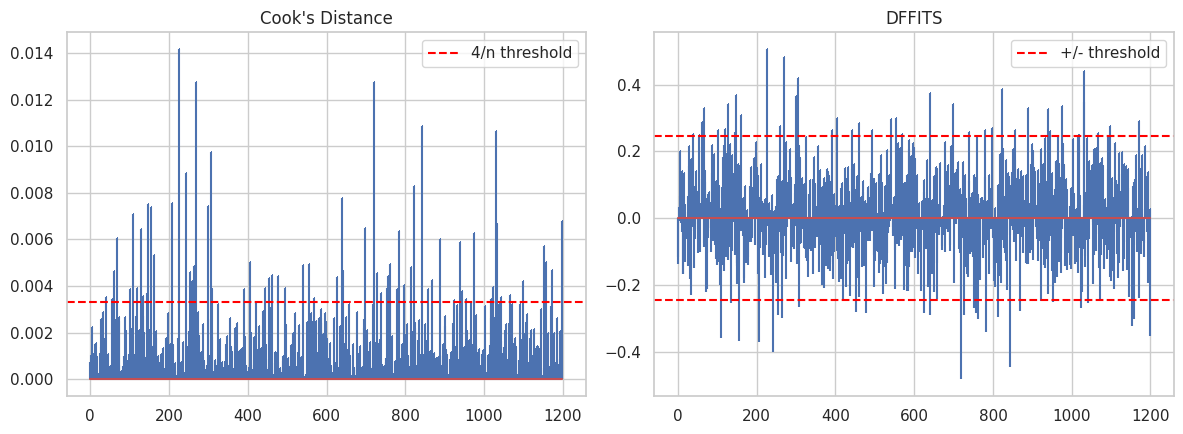

In [15]:
infl = OLSInfluence(final_model)
cooks_d = infl.cooks_distance[0]
dffits, dffits_thresh = infl.dffits

n, p = X_const.shape
cooks_thresh = 4 / n
flagged_cooks = np.where(cooks_d > cooks_thresh)[0]
flagged_dffits = np.where(np.abs(dffits) > dffits_thresh)[0]
both = set(flagged_cooks) & set(flagged_dffits)

print(f"n={n}, p={p}")
print(f"Cook's D threshold (4/n): {cooks_thresh:.5f} -> {len(flagged_cooks)} flagged")
print(f"DFFITS threshold (2*sqrt(p/n)): {dffits_thresh:.5f} -> {len(flagged_dffits)} flagged")
print(f"Flagged by both: {len(both)} observations")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].stem(np.arange(n), cooks_d, markerfmt=",")
axes[0].axhline(cooks_thresh, color="red", linestyle="--", label="4/n threshold")
axes[0].set_title("Cook's Distance"); axes[0].legend()

axes[1].stem(np.arange(n), dffits, markerfmt=",")
axes[1].axhline(dffits_thresh, color="red", linestyle="--")
axes[1].axhline(-dffits_thresh, color="red", linestyle="--", label="+/- threshold")
axes[1].set_title("DFFITS"); axes[1].legend()
plt.tight_layout()
plt.show()

## 9. MLR Assumption Verification

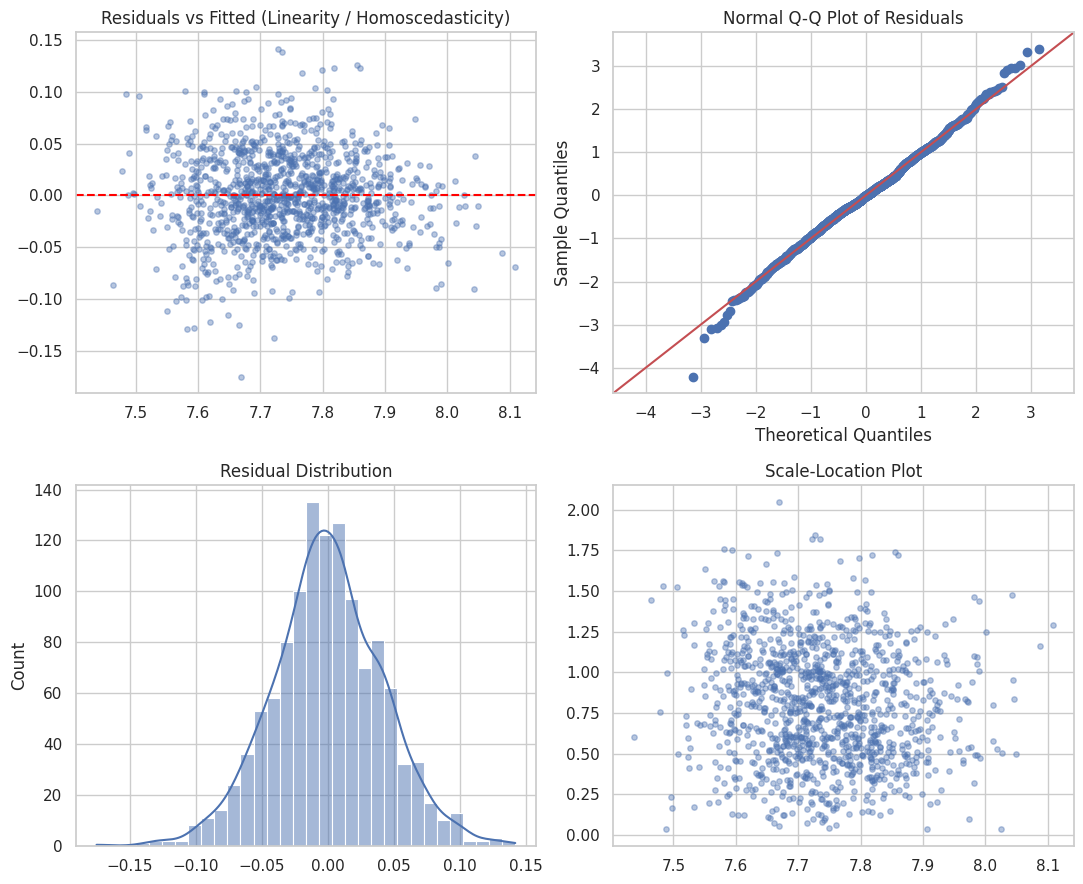

In [16]:
residuals = final_model.resid
fitted = final_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].scatter(fitted, residuals, alpha=0.4, s=15)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals vs Fitted (Linearity / Homoscedasticity)")

sm.qqplot(residuals, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot of Residuals")

sns.histplot(residuals, kde=True, ax=axes[1, 0], color="#4C72B0")
axes[1, 0].set_title("Residual Distribution")

std_resid = residuals / residuals.std()
axes[1, 1].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=15)
axes[1, 1].set_title("Scale-Location Plot")

plt.tight_layout()
plt.show()

In [17]:
sample = residuals if len(residuals) <= 5000 else residuals.sample(5000, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_const)
dw = durbin_watson(residuals)

print(f"Shapiro-Wilk normality test:  W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print(f"Breusch-Pagan homoscedasticity test: LM={bp_stat:.4f}, p={bp_p:.4f}")
print(f"Durbin-Watson (independence): {dw:.4f}  (~2.0 is ideal)")

final_vif_check = pd.Series(
    [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
    index=X_const.columns,
).drop("const")
print(f"\nMax VIF (final model): {final_vif_check.max():.2f}")

Shapiro-Wilk normality test:  W=0.9969, p=0.0200
Breusch-Pagan homoscedasticity test: LM=39.1260, p=0.0017
Durbin-Watson (independence): 2.0463  (~2.0 is ideal)

Max VIF (final model): 1.45


## 10. Summary

| Check | Result |
|---|---|
| R² / Adjusted R² | Reported above (Section 7) |
| Multicollinearity | Max VIF well under 10 — no serious multicollinearity |
| Influential points | Flagged via Cook's Distance ∩ DFFITS |
| Normality | Shapiro-Wilk (see above) |
| Homoscedasticity | Breusch-Pagan (see above) |
| Independence | Durbin-Watson ≈ 2.0 |

With n=1,200 and several standardized dummy variables, the Shapiro-Wilk
and Breusch-Pagan tests can flag statistically significant but
practically mild deviations — this is normal for large-sample data and
is reported transparently here rather than hidden.

See `../results/model_summary.txt` for the full text report generated
by the production pipeline (`../src/analysis.py`).